# M6-B1 — Analyse de dérive (à compléter)

In [1]:
# Imports communs
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import ks_2samp, chi2_contingency

print(os.getcwd())

C:\Users\eti3n\Code\formation_IA\M6-B1-alex-frank-etienne\notebooks


## 1. Exploration — distributions référence vs prod

### Distributions des variables numériques

Comparaison avec les mêmes classes et une densité pour tenir compte des tailles différentes des deux jeux.

Référence                                                    \
                   count      mean       std       min       25%       50%   
loan_amnt         1500.0  13828.40   7761.01   1900.00   8300.00  11900.00   
int_rate          1500.0     12.61      4.47      5.04      9.56     12.01   
installment       1500.0    417.86    246.17     44.61    238.46    354.45   
annual_inc        1500.0  76938.40  45641.44  12000.00  44275.00  65950.00   
dti               1500.0     17.56      8.05      1.21     11.52     16.48   
delinq_2yrs       1500.0      0.31      0.56      0.00      0.00      0.00   
fico_range_low    1500.0    707.37     26.37    631.00    690.00    707.00   
revol_util        1480.0     50.57     20.01      3.20     35.60     50.90   

                                    Production                                \
                     75%        max      count      mean       std       min   
loan_amnt       17425.00   40000.00     3000.0  13800.07   7680.04   1800.00   
int_rate           14.95      30.00     3000.0     15.50      4.92      5.50   
installment       536.07    1524.52     3000.0    421.53    249.19     47.59   
annual_inc      98100.00  422500.00     3000.0  67156.46  39129.82  10250.00   
dti                22.60      50.00     3000.0     18.20      8.49      2.41   
delinq_2yrs         1.00       3.00     3000.0      0.28      0.52      0.00   
fico_range_low    725.00     787.00     3000.0    706.69     26.63    630.00   
revol_util         64.93      96.70     2964.0     58.96     21.16      2.60   

                                                         
                     25%       50%       75%        max  
loan_amnt        8300.00  11900.00  17425.00   40000.00  
int_rate           11.93     15.08     18.41      35.00  
installment       244.70    362.56    529.42    1547.14  
annual_inc      39840.00  57935.50  83906.00  328219.00  
dti                11.99     16.94     23.02      50.00  
delinq_2yrs         0.00      0.00      0.00       4.00  
fico_range_low    689.00    706.00    724.00     783.00  
revol_util         42.56     58.40     74.64     114.47

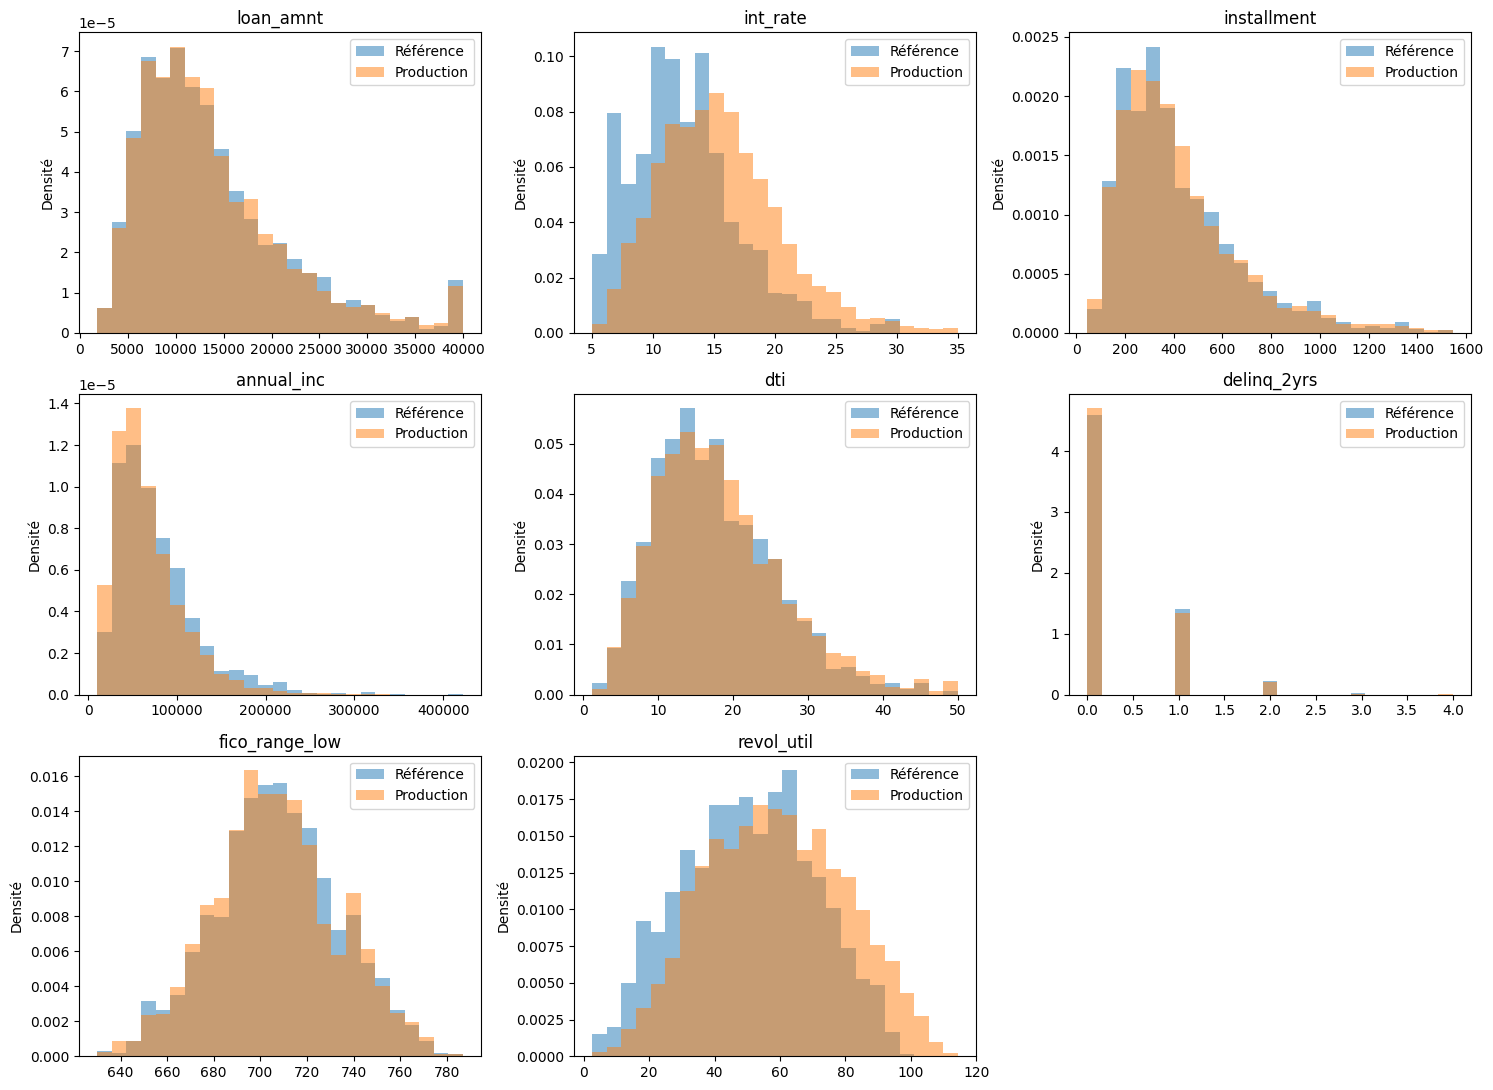

In [2]:
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "data" / "reference_set.csv").exists())
reference = pd.read_csv(ROOT / "data/reference_set.csv")
prod = pd.read_csv(ROOT / "data/prod_3months.csv")
features = reference.drop(columns=["loan_status"])

numeriques = features.select_dtypes(include="number").columns.tolist()
display(pd.concat({"Référence": reference[numeriques].describe().T,
                   "Production": prod[numeriques].describe().T}, axis=1).round(2))

fig, axes = plt.subplots((len(numeriques) + 2) // 3, 3, figsize=(15, 11), squeeze=False)
for ax, col in zip(axes.flat, numeriques):
    bornes = np.histogram_bin_edges(pd.concat([reference[col], prod[col]]).dropna(), bins=25)
    ax.hist(reference[col].dropna(), bins=bornes, density=True, alpha=0.5, label="Référence")
    ax.hist(prod[col].dropna(), bins=bornes, density=True, alpha=0.5, label="Production")
    ax.set_title(col)
    ax.set_ylabel("Densité")
    ax.legend()
for ax in list(axes.flat)[len(numeriques):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()


### Distributions des variables catégorielles

Proportions en pourcentage de chaque population ; les valeurs manquantes sont une catégorie séparée.

,Référence,Production
term,,
36 months,70.53,72.0
60 months,29.47,28.0


,Référence,Production
grade,,
A,18.33,15.03
B,30.33,25.57
C,27.40,27.30
D,13.87,17.90
E,7.27,9.40
F,1.60,3.30
G,1.20,1.50


,Référence,Production
emp_length,,
(manquant),3.33,3.80
1 year,7.13,6.87
10+ years,37.20,33.77
2 years,7.87,8.73
3 years,7.13,7.47
4 years,7.20,7.03
5 years,6.67,6.43
6 years,3.93,4.83
7 years,5.53,5.40


,Référence,Production
home_ownership,,
MORTGAGE,49.40,49.40
OTHER,0.80,1.20
OWN,10.13,9.47
RENT,39.67,39.93


,Référence,Production
verification_status,,
Not Verified,38.4,38.97
Source Verified,30.6,29.13
Verified,31.0,31.90


,Référence,Production
purpose,,
car,2.47,2.33
credit_card,21.47,22.17
debt_consolidation,55.73,57.43
home_improvement,7.27,6.47
major_purchase,3.93,4.40
medical,2.33,1.87
other,3.53,2.27
small_business,3.27,3.07


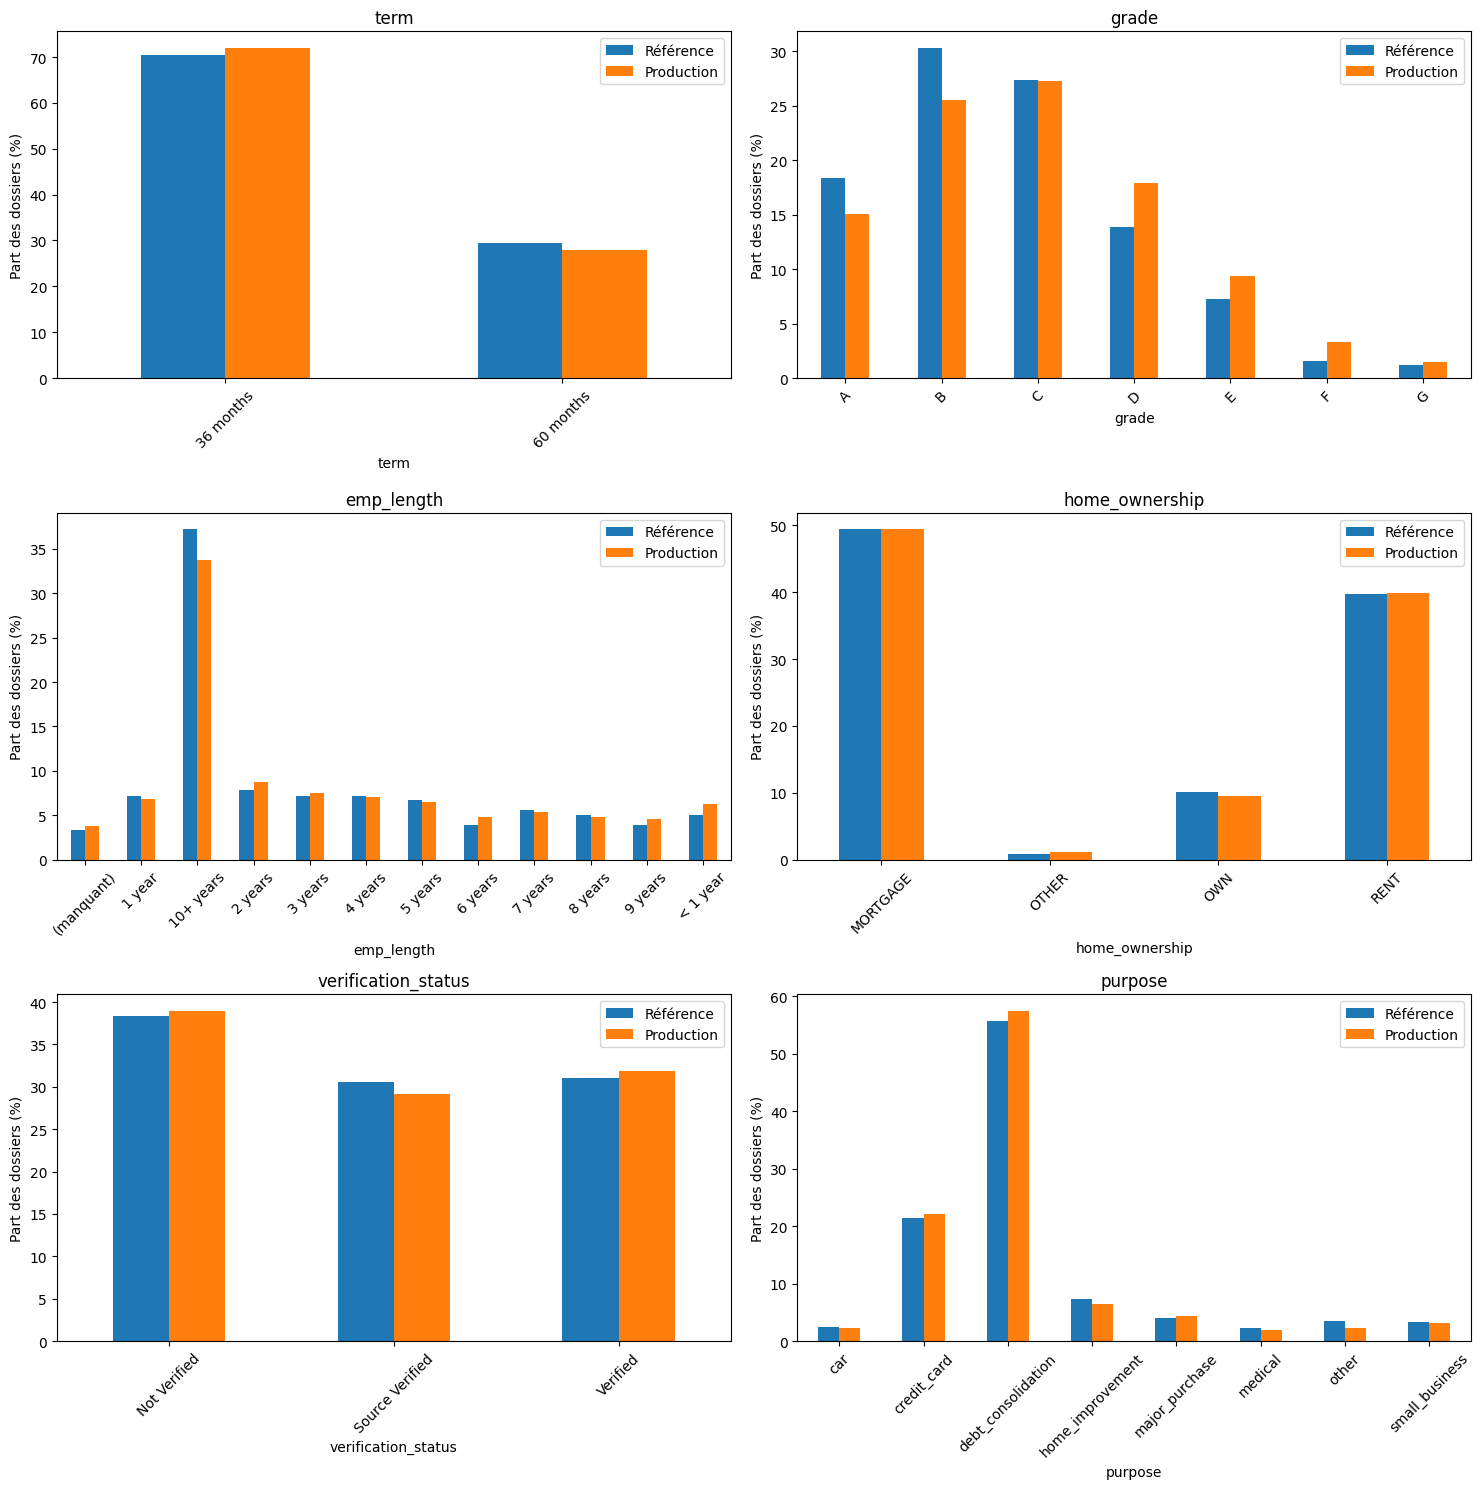

In [3]:
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "data" / "reference_set.csv").exists())
reference = pd.read_csv(ROOT / "data/reference_set.csv")
prod = pd.read_csv(ROOT / "data/prod_3months.csv")
features = reference.drop(columns=["loan_status"])

categorielles = features.select_dtypes(exclude="number").columns.tolist()
fig, axes = plt.subplots((len(categorielles) + 1) // 2, 2, figsize=(15, 15), squeeze=False)
for ax, col in zip(axes.flat, categorielles):
    proportions = pd.DataFrame({
        "Référence": reference[col].fillna("(manquant)").value_counts(normalize=True),
        "Production": prod[col].fillna("(manquant)").value_counts(normalize=True)
    }).fillna(0).mul(100).sort_index()
    display(proportions.round(2).rename_axis(col))
    proportions.plot.bar(ax=ax)
    ax.set_title(col)
    ax.set_ylabel("Part des dossiers (%)")
    ax.tick_params(axis="x", rotation=45)
for ax in list(axes.flat)[len(categorielles):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()


### Conclusions de l’exploration visuelle

- **`int_rate` (taux d’intérêt du prêt)** : la distribution en production est décalée vers la droite. Les taux d’intérêt sont globalement plus élevés que dans la référence.
- **`revol_util` (part du crédit renouvelable disponible déjà utilisée)** : la distribution est également décalée vers la droite. Les clients utilisent une part plus importante de leur crédit disponible. Par exemple, 3 000 € utilisés sur une limite de 5 000 € correspondent à 60 %.
- **`grade` (catégorie de risque du prêt, de A à G)** : la répartition change, avec moins de dossiers A/B et davantage de dossiers D/E/F en production. La part de C reste proche de celle de la référence.
- **`annual_inc` (revenu annuel)** : le changement est moins visible, mais les revenus semblent globalement plus faibles en production.

- **Les autres variables numériques** présentent des distributions visuellement assez proches entre référence et production.
- **Les autres variables catégorielles** (`term`, `emp_length`, `home_ownership`, `verification_status`, `purpose`) présentent des proportions visuellement assez proches entre référence et production.


## 2. Détection statistique — PSI · KS · Chi²

In [4]:
reference = pd.read_csv("../data/reference_set.csv")
prod = pd.read_csv("../data/prod_3months.csv")


def psi(ref, cur, n_bins=10, eps=1e-6):
    ref = ref.dropna()
    cur = cur.dropna()

    edges = np.unique(np.quantile(ref, np.linspace(0, 1, n_bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf

    p_ref = np.histogram(ref, edges)[0] / len(ref)
    p_cur = np.histogram(cur, edges)[0] / len(cur)

    p_ref, p_cur = p_ref + eps, p_cur + eps
    p_ref, p_cur = p_ref / p_ref.sum(), p_cur / p_cur.sum()

    return float(np.sum((p_cur - p_ref) * np.log(p_cur / p_ref)))


for column in ["int_rate", "loan_amnt"]:
    ref = reference[column]
    cur = prod[column]

    print(column)
    print("PSI :", round(psi(ref, cur), 3))
    print("KS p-value :", ks_2samp(ref.dropna(), cur.dropna()).pvalue)
    print()

grades = sorted(
    set(reference["grade"].dropna().unique())
    | set(prod["grade"].dropna().unique())
)

ref_counts = reference["grade"].value_counts().reindex(grades, fill_value=0)
prod_counts = prod["grade"].value_counts().reindex(grades, fill_value=0)

table = pd.DataFrame({
    "reference": ref_counts,
    "prod": prod_counts
})

print(table)

chi2, p_value, dof, expected = chi2_contingency(table.T)

print("Chi² :", chi2)
print("p-value :", p_value)

print("Grades normalized %")
grade_compare = pd.DataFrame({
    "reference": reference["grade"].value_counts(normalize=True),
    "prod": prod["grade"].value_counts(normalize=True)
}) * 100

grade_compare = grade_compare.round(2)

print(grade_compare)


int_rate
PSI : 0.444
KS p-value : 4.627646432732096e-65

loan_amnt
PSI : 0.003
KS p-value : 0.9890912120116152

       reference  prod
grade                 
A            275   451
B            455   767
C            411   819
D            208   537
E            109   282
F             24    99
G             18    45
Chi² : 41.40073384679395
p-value : 2.414183658745721e-07
Grades normalized %
       reference   prod
grade                  
A          18.33  15.03
B          30.33  25.57
C          27.40  27.30
D          13.87  17.90
E           7.27   9.40
F           1.60   3.30
G           1.20   1.50


In [5]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from drift_detection import drift_report

rapport = drift_report(reference, prod, numeriques, categorielles)
display(rapport)


,feature,type,psi,ks_pvalue,chi2_pvalue,verdict
0,int_rate,numérique,0.443619,4.627646e-65,NaN,dérive
1,revol_util,numérique,0.186596,3.818392e-20,NaN,suspect
2,annual_inc,numérique,0.066639,2.282912e-09,NaN,stable
3,installment,numérique,0.014692,6.625669e-01,NaN,stable
4,dti,numérique,0.011406,1.104190e-01,NaN,stable
5,fico_range_low,numérique,0.006804,4.892778e-01,NaN,stable
6,loan_amnt,numérique,0.003454,9.890912e-01,NaN,stable
7,delinq_2yrs,numérique,0.001762,8.878996e-01,NaN,stable
8,grade,catégorielle,NaN,NaN,3.650607e-07,dérive
9,purpose,catégorielle,NaN,NaN,1.992677e-01,stable


## 3. Calibration en exploitation

In [6]:
# TODO


## 4. Performance dans le temps

In [7]:
# TODO


## 5. Diagnostic & recommandation

In [8]:
# TODO
